# Energy Consumption Forecasting

# Load & Index Data

In [1]:
# If these imports fail, Jupyter will print an error.
# In that case, uncomment the !pip lines below to install.

# !pip install pandas numpy matplotlib seaborn statsmodels prophet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

In [5]:
# 1. Read the .txt file, telling pandas that missing values are marked '?'
df = pd.read_csv(
    "E:/project_Energy_Python/household_power_consumption.txt",
    sep=';',                        # columns are separated by semicolons
    parse_dates={'Datetime':['Date','Time']},
    infer_datetime_format=True,
    na_values=['?'],                # '?' means missing
    low_memory=False
)

# 2. Make the combined Date+Time your row index
df.set_index('Datetime', inplace=True)

# 3. Look at the first 5 rows
df.head()

C:\Users\DELL-PC\AppData\Local\Temp\ipykernel_17672\4268983393.py:2: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(
C:\Users\DELL-PC\AppData\Local\Temp\ipykernel_17672\4268983393.py:2: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv(
C:\Users\DELL-PC\AppData\Local\Temp\ipykernel_17672\4268983393.py:2: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv(


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


# Handling Missing Values

In [7]:
# How many missing?
print("Missing per column:\n", df.isna().sum())

# Forward-fill to carry the last good reading forward
df = df.fillna(method='ffill')

# Double-check there are no more gaps
print("Any missing now? ", df.isna().any().any())

Missing per column:
 Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64


C:\Users\DELL-PC\AppData\Local\Temp\ipykernel_17672\2341921125.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


Any missing now?  False


# Quick Visualization

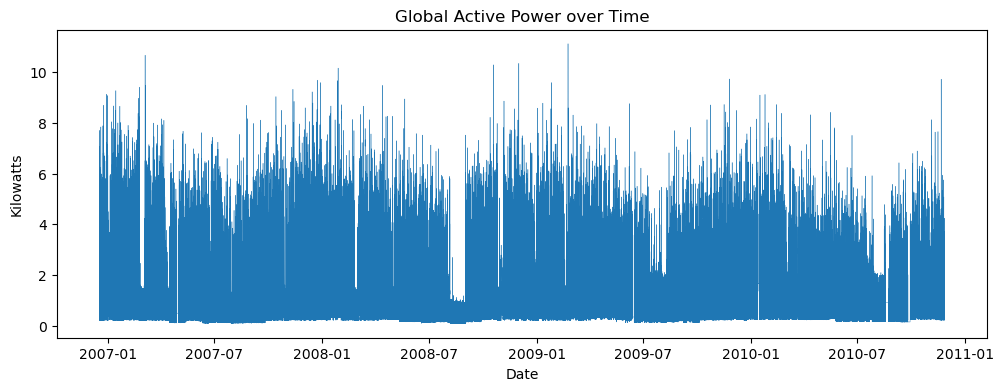

In [9]:
plt.figure(figsize=(12,4))
plt.plot(df['Global_active_power'], lw=0.3)
plt.title('Global Active Power over Time')
plt.ylabel('Kilowatts')
plt.xlabel('Date')
plt.show()

# Zooming Into a Month

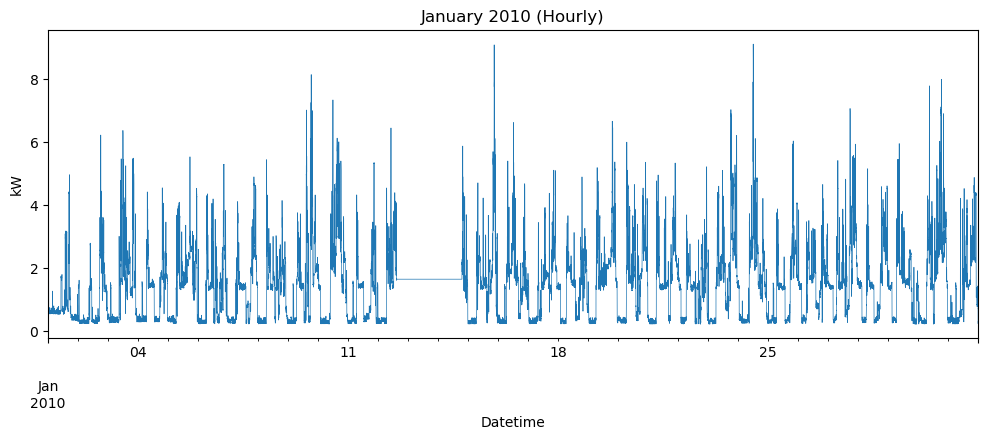

In [17]:
df['Global_active_power'].loc['2010-01'].plot(
    figsize=(12,4), lw=0.5
)
plt.title('January 2010 (Hourly)')
plt.ylabel('kW')
plt.show()

# Daily Aggregation & Decomposition

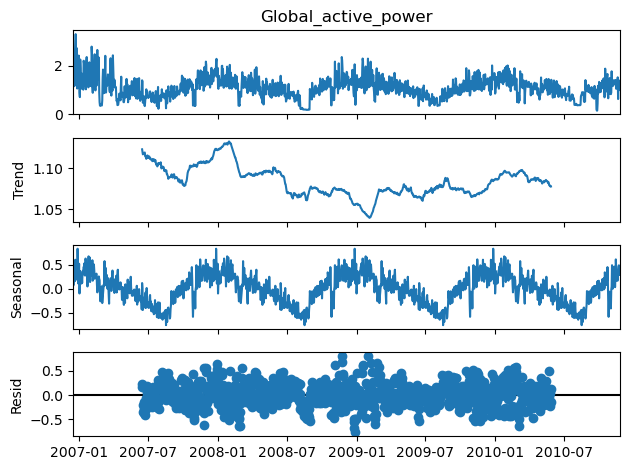

In [20]:
daily = df['Global_active_power'].resample('D').mean()

# Decompose into trend/seasonality/residual
result = seasonal_decompose(daily, model='additive', period=365)
result.plot()
plt.tight_layout()
plt.show()

# Train/Test Split

In [22]:
from sklearn.metrics import mean_absolute_error

# Last 30 days for testing
train = daily.iloc[:-30]
test  = daily.iloc[-30:]

# Baseline Forecaste

In [26]:
from sklearn.metrics import mean_absolute_error

# daily is your full Series of daily averages:
# daily = df['Global_active_power'].resample('D').mean()

# 1) shift the whole thing
baseline_full = daily.shift(1)

# 2) grab exactly the same dates as your test set
baseline_pred = baseline_full.loc[test.index]

# 3) now compute MAE
mae_baseline = mean_absolute_error(test, baseline_pred)
print(f"Baseline MAE: {mae_baseline:.3f}")

Baseline MAE: 0.249


# SARIMA Model

In [31]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(train,
                order=(1,1,1),
                seasonal_order=(1,1,1,7),
                enforce_stationarity=False,
                enforce_invertibility=False
               ).fit(disp=False)

forecast = model.get_forecast(steps=30).predicted_mean
print("SARIMA MAE:", mean_absolute_error(test, forecast))

SARIMA MAE: 0.18286713623249923


# Plot & Compare

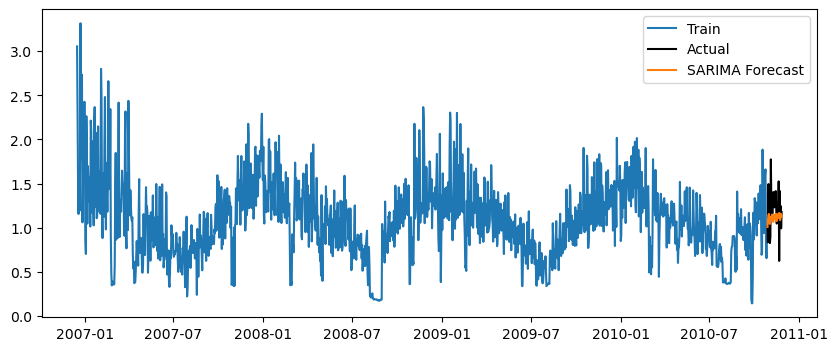

In [33]:
plt.figure(figsize=(10,4))
plt.plot(train.index, train, label='Train')
plt.plot(test.index,  test,  label='Actual', color='black')
plt.plot(test.index,  forecast, label='SARIMA Forecast')
plt.legend()
plt.show()